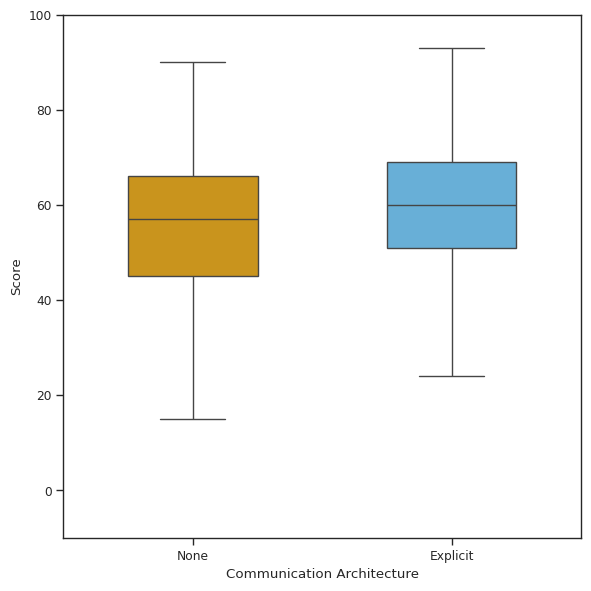

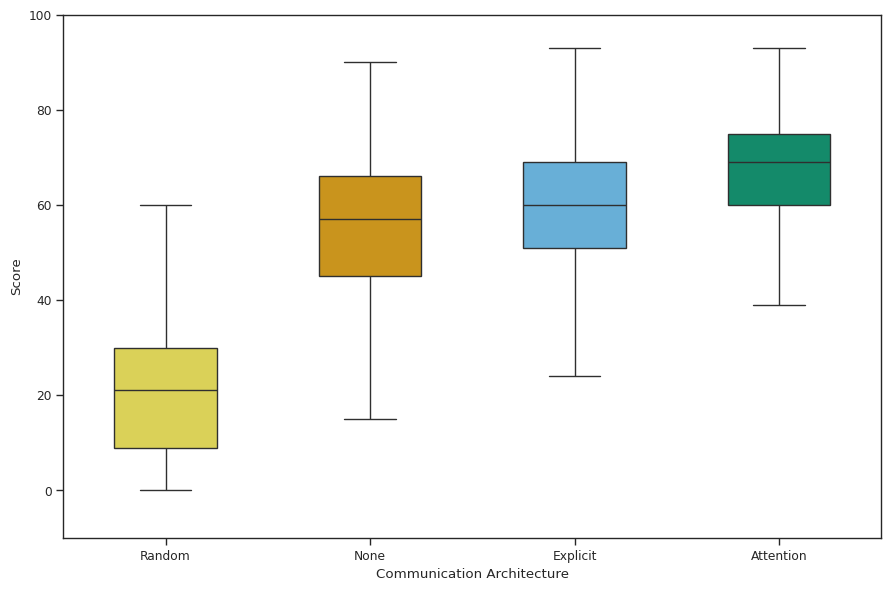

count    1000.000000
mean        1.010000
std         1.948255
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.000000
Name: score_red, dtype: float64
count    1000.000000
mean        1.010000
std         1.948255
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        14.000000
Name: score_red, dtype: float64


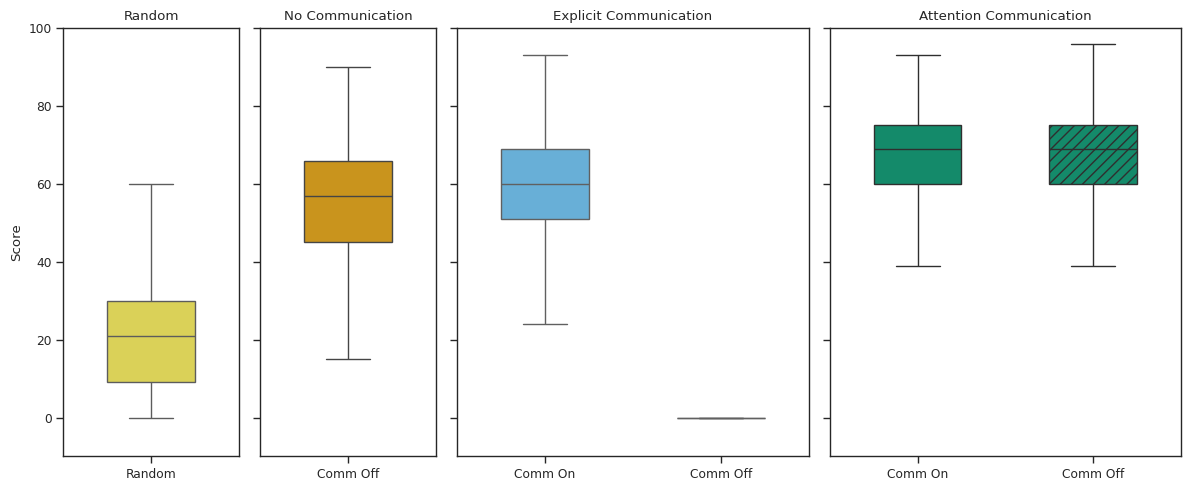

--- Statistical Significance Results ---
Explicit vs Attention (Global): p = 0.0000
Explicit Ablation (On vs Off): p = 0.0000
Attention Ablation (On vs Off): p = 0.3964


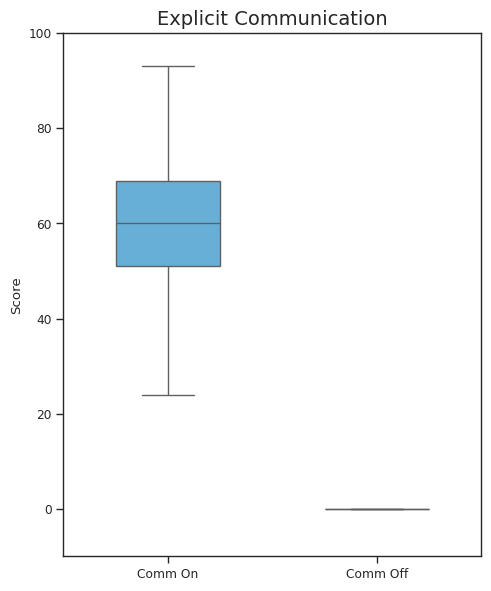

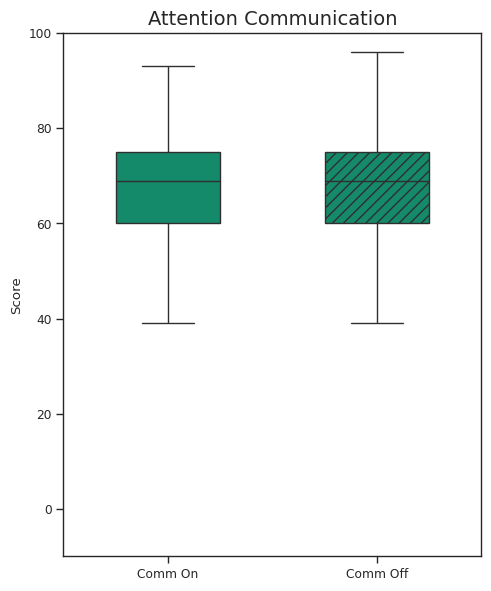

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind
from matplotlib.patches import Patch

# Professional Paper Setting
PALETTE = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#D55E00']
sns.set_theme(style="ticks", context="paper", palette=PALETTE)

# 1. Load Data
none_none = pd.read_csv('none_none_1_0.csv')['score_red']
copy_copy = pd.read_csv('copy_copy_1_0.csv')['score_red']
copy_none = pd.read_csv('copy_none_1_0.csv')['score_red']
attn_attn = pd.read_csv('attention_attention_1_0.csv')['score_red']
attn_none = pd.read_csv('attention_none_1_0.csv')['score_red']
random_random = pd.read_csv('random_1_0.csv')['score_red']

# --- FIGURE 1: GLOBAL COMPARISON ---
fig, ax = plt.subplots(figsize=(6, 6))
global_df = pd.DataFrame({
    "Architecture": ["None"] * len(none_none) + ["Explicit"] * len(copy_copy),
    "Score": pd.concat([none_none, copy_copy], ignore_index=True)
})

sns.boxplot(
    data=global_df,
    x="Architecture",
    y="Score",
    hue="Architecture",
    showfliers=False,
    width=0.5,
    palette=PALETTE[:2],
    legend=False,
    ax=ax
)

ax.set_ylabel('Score')
ax.set_xlabel('Communication Architecture')
ax.set_ylim(-10, 100)
plt.tight_layout()
plt.show()

# --- FIGURE 1: GLOBAL COMPARISON ---
fig, ax = plt.subplots(figsize=(9, 6))
global_df = pd.DataFrame({
    "Architecture": ["Random"] * len(random_random) + ["None"] * len(none_none) + ["Explicit"] * len(copy_copy) + ["Attention"] * len(attn_attn),
    "Score": pd.concat([random_random, none_none, copy_copy, attn_attn], ignore_index=True)
})

sns.boxplot(
    data=global_df,
    x="Architecture",
    y="Score",
    hue="Architecture",
    showfliers=False,
    width=0.5,
    palette=[PALETTE[3], PALETTE[0], PALETTE[1], PALETTE[2]],
    legend=False,
    ax=ax
)

ax.set_ylabel('Score')
ax.set_xlabel('Communication Architecture')
ax.set_ylim(-10, 100)
plt.tight_layout()
plt.show()

# --- FIGURE 2: ABLATION STUDY (NONE NARROW ON THE LEFT) ---
fig, (ax3, ax0, ax1, ax2) = plt.subplots(
    1, 4, figsize=(12, 5), sharey=True,
    gridspec_kw={"width_ratios": [0.5, 0.5, 1.0, 1.0]}
)

# Random (narrow, left)
df_random = pd.DataFrame({
    "Execution": ["Random"] * len(random_random),
    "Score": random_random.reset_index(drop=True)
})
sns.boxplot(
    data=df_random,
    x="Execution",
    y="Score",
    hue="Execution",
    order=["Random"],
    ax=ax3,
    showfliers=False,
    width=0.5,
    dodge=False,
    palette={"Random": PALETTE[3]},
    legend=False
)
ax3.set_title('Random')
ax3.set_xlabel('')
ax3.set_ylabel('Score')
ax3.set_ylim(-10, 100)

print(copy_none.describe())

# No Communication (narrow, left)
df_none = pd.DataFrame({
    "Execution": ["Comm Off"] * len(none_none),
    "Score": none_none.reset_index(drop=True)
})
sns.boxplot(
    data=df_none,
    x="Execution",
    y="Score",
    hue="Execution",
    order=["Comm Off"],
    ax=ax0,
    showfliers=False,
    width=0.5,
    dodge=False,
    palette={"Comm Off": PALETTE[0]},
    legend=False
)
ax0.set_title('No Communication')
ax0.set_xlabel('')
ax0.set_ylabel('Score')
ax0.set_ylim(-10, 100)

print(copy_none.describe())

# Explicit: Comm On vs Comm Off
df_copy = pd.DataFrame({
    "Execution": ["Comm On"] * len(copy_copy) + ["Comm Off"] * len(copy_none),
    "Score": pd.concat([copy_copy, copy_none], ignore_index=True)
})
sns.boxplot(
    data=df_copy,
    x="Execution",
    y="Score",
    hue="Execution",
    order=["Comm On", "Comm Off"],
    ax=ax1,
    showfliers=False,
    width=0.5,
    dodge=False,
    palette={"Comm On": PALETTE[1], "Comm Off": PALETTE[1]},
    legend=False
)
if len(ax1.patches) >= 2:
    ax1.patches[1].set_hatch('///')
    # ax1.patches[1].set_edgecolor('white')

ax1.set_title('Explicit Communication')
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_ylim(-10, 100)

# Attention: Comm On vs Comm Off
df_attn = pd.DataFrame({
    "Execution": ["Comm On"] * len(attn_attn) + ["Comm Off"] * len(attn_none),
    "Score": pd.concat([attn_attn, attn_none], ignore_index=True)
})
sns.boxplot(
    data=df_attn,
    x="Execution",
    y="Score",
    hue="Execution",
    order=["Comm On", "Comm Off"],
    ax=ax2,
    showfliers=False,
    width=0.5,
    dodge=False,
    palette={"Comm On": PALETTE[2], "Comm Off": PALETTE[2]},
    legend=False
)
if len(ax2.patches) >= 2:
    ax2.patches[1].set_hatch('///')
    # ax2.patches[1].set_edgecolor('white')

ax2.set_title('Attention Communication')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_ylim(-10, 100)

# Manual legends
legend_elements0 = [Patch(facecolor=PALETTE[0], label='Comm Off')]
legend_elements1 = [
    Patch(facecolor=PALETTE[1], label='Comm On'),
    Patch(facecolor=PALETTE[1], hatch='///', edgecolor='white', label='Comm Off')
]
legend_elements2 = [
    Patch(facecolor=PALETTE[2], label='Comm On'),
    Patch(facecolor=PALETTE[2], hatch='///', edgecolor='white', label='Comm Off')
]

# ax0.legend(handles=legend_elements0, loc='lower left')
# ax1.legend(handles=legend_elements1, loc='lower left')
# ax2.legend(handles=legend_elements2, loc='lower left')

for a in (ax0, ax1, ax2, ax3):
    a.set_ylim(-10, 100)

plt.tight_layout()
plt.show()

# 3. Statistical Summary for Paper Text
print("--- Statistical Significance Results ---")
_, p_glob = ttest_ind(copy_copy, attn_attn)
print(f"Explicit vs Attention (Global): p = {p_glob:.4f}")
_, p_copy = ttest_ind(copy_copy, copy_none)
print(f"Explicit Ablation (On vs Off): p = {p_copy:.4f}")
_, p_attn = ttest_ind(attn_attn, attn_none)
print(f"Attention Ablation (On vs Off): p = {p_attn:.4f}")


# --- FIGURE: EXPLICIT COMMUNICATION (INDIVIDUAL PLOT) ---
fig_exp, ax_exp = plt.subplots(figsize=(5, 6))
df_copy = pd.DataFrame({
    "Execution": ["Comm On"] * len(copy_copy) + ["Comm Off"] * len(copy_none),
    "Score": pd.concat([copy_copy, copy_none], ignore_index=True)
})
sns.boxplot(
    data=df_copy, x="Execution", y="Score", hue="Execution",
    order=["Comm On", "Comm Off"], ax=ax_exp, showfliers=False,
    width=0.5, dodge=False, palette={"Comm On": PALETTE[1], "Comm Off": PALETTE[1]}
)
# Remove legend and apply hatching
if ax_exp.get_legend(): ax_exp.get_legend().remove()
# Apply hatching to the second box (Comm Off)
if len(ax_exp.patches) >= 2:
    ax_exp.patches[1].set_hatch('///')
    # ax_exp.patches[1].set_edgecolor('white')

ax_exp.set_title('Explicit Communication', fontsize=14)
ax_exp.set_ylabel('Score')
ax_exp.set_xlabel('')
ax_exp.set_ylim(-10, 100)
plt.tight_layout()

# --- FIGURE: ATTENTION COMMUNICATION (INDIVIDUAL PLOT) ---
fig_attn, ax_attn = plt.subplots(figsize=(5, 6))
df_attn = pd.DataFrame({
    "Execution": ["Comm On"] * len(attn_attn) + ["Comm Off"] * len(attn_none),
    "Score": pd.concat([attn_attn, attn_none], ignore_index=True)
})
sns.boxplot(
    data=df_attn, x="Execution", y="Score", hue="Execution",
    order=["Comm On", "Comm Off"], ax=ax_attn, showfliers=False,
    width=0.5, dodge=False, palette={"Comm On": PALETTE[2], "Comm Off": PALETTE[2]}
)
# Remove legend and apply hatching
if ax_attn.get_legend(): ax_attn.get_legend().remove()
# Apply hatching to the second box (Comm Off)
if len(ax_attn.patches) >= 2:
    ax_attn.patches[1].set_hatch('///')
    # ax_attn.patches[1].set_edgecolor('white')

ax_attn.set_title('Attention Communication', fontsize=14)
ax_attn.set_ylabel('Score')
ax_attn.set_xlabel('')
ax_attn.set_ylim(-10, 100)
plt.tight_layout()

# Display individual plots
plt.show()


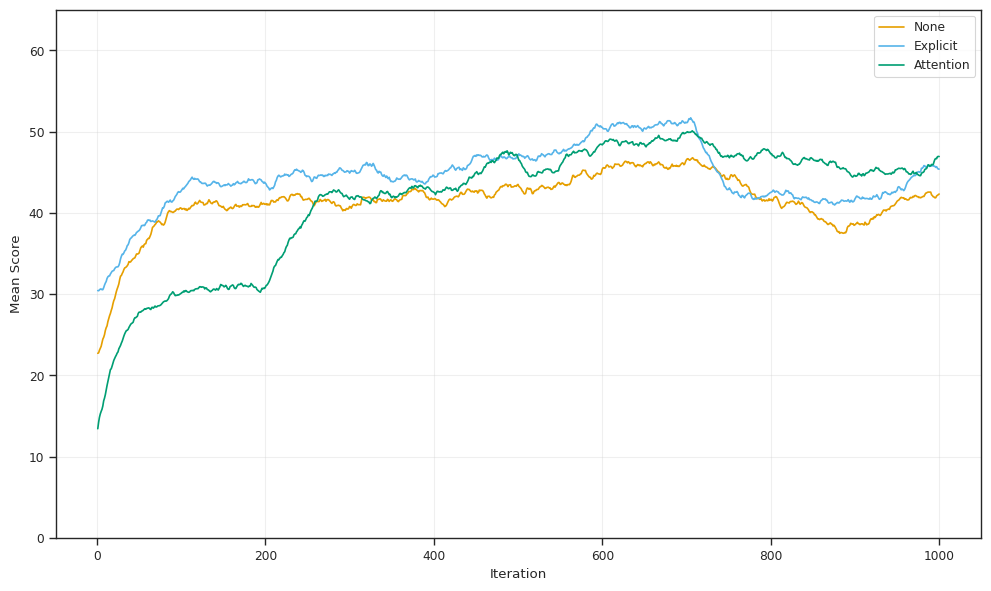

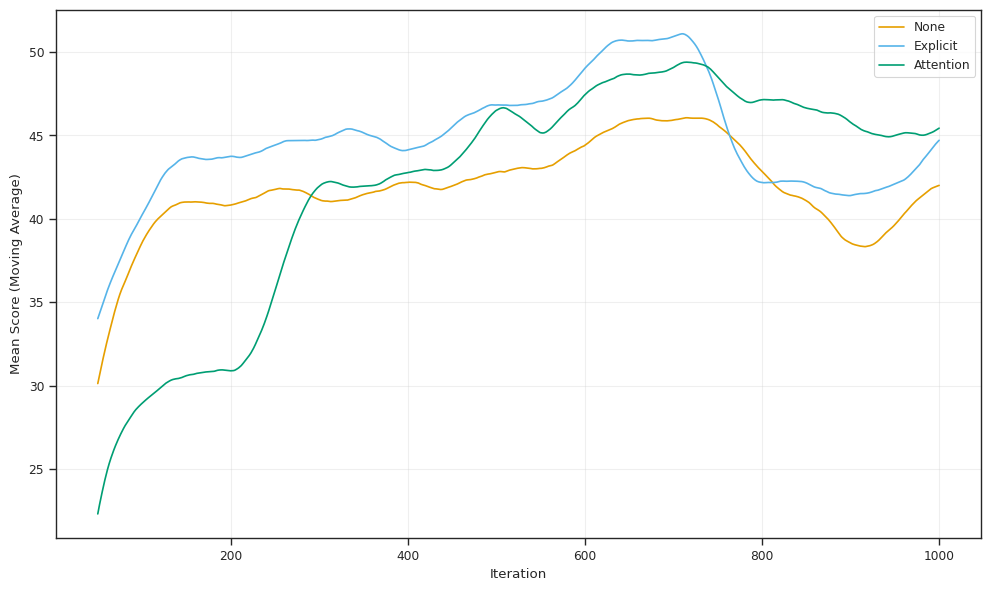

In [3]:
# Load and merge training logs with clean unique indices
# training_none = pd.concat(
#     [pd.read_csv('training_none_0_500.csv'), pd.read_csv('training_none_500_1500.csv')],
#     ignore_index=True
# )
# training_copy = pd.concat(
#     [pd.read_csv('training_copy_0_500.csv'), pd.read_csv('training_copy_500_1500.csv')],
#     ignore_index=True
# )
# training_attention = pd.concat(
#     [pd.read_csv('training_attention_0_500.csv'), pd.read_csv('training_attention_500_1500.csv')],
#     ignore_index=True
# )

training_none = pd.read_csv('training_none_0_1000.csv')
training_copy = pd.read_csv('training_copy_0_1000.csv')
training_attention = pd.read_csv('training_attention_0_1000.csv')

palette_map = {"None": PALETTE[0], "Explicit": PALETTE[1], "Attention": PALETTE[2]}

# Raw training curves
plt.figure(figsize=(10, 6))
sns.lineplot(data=training_none, x='training_iteration', y='env_runners/red_team_score_mean', label='None', color=palette_map["None"])
sns.lineplot(data=training_copy, x='training_iteration', y='env_runners/red_team_score_mean', label='Explicit', color=palette_map["Explicit"])
sns.lineplot(data=training_attention, x='training_iteration', y='env_runners/red_team_score_mean', label='Attention', color=palette_map["Attention"])
plt.xlabel('Iteration')
plt.ylabel('Mean Score')
plt.ylim(0, 65)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Moving-average curves
window_size = 50
plt.figure(figsize=(10, 6))
sns.lineplot(data=training_none, x='training_iteration', y=training_none['env_runners/red_team_score_mean'].rolling(window_size).mean(), label='None', color=palette_map["None"])
sns.lineplot(data=training_copy, x='training_iteration', y=training_copy['env_runners/red_team_score_mean'].rolling(window_size).mean(), label='Explicit', color=palette_map["Explicit"])
sns.lineplot(data=training_attention, x='training_iteration', y=training_attention['env_runners/red_team_score_mean'].rolling(window_size).mean(), label='Attention', color=palette_map["Attention"])
plt.xlabel('Iteration')
plt.ylabel('Mean Score (Moving Average)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


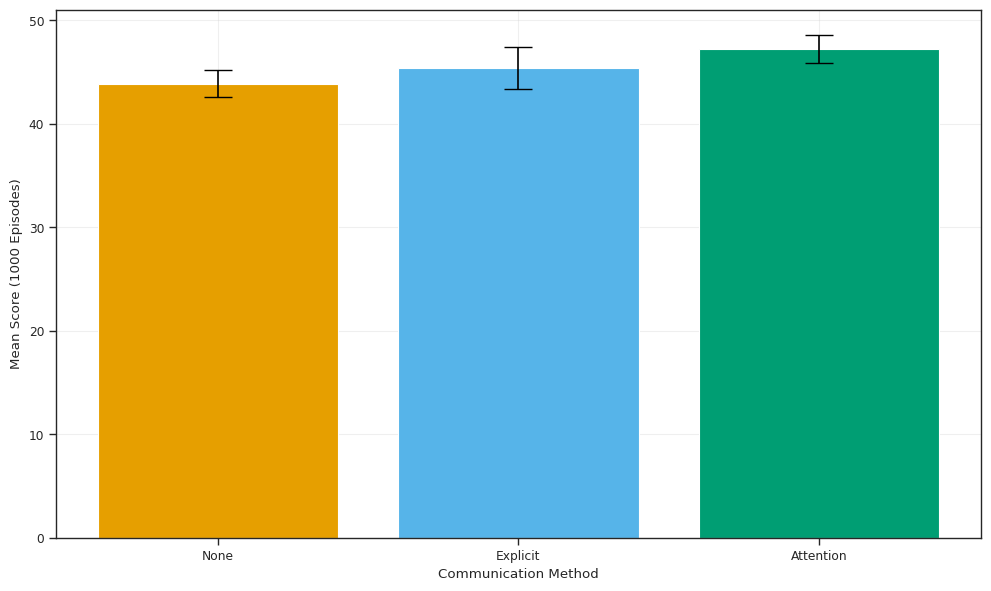

T-test None vs Explicit: p = 0.1938
T-test None vs Attention: p = 0.0038
T-test Explicit vs Attention: p = 0.1270


In [6]:
# Calculate mean and std for each architecture

training_results = pd.read_csv('training_results.csv')
training_df = pd.DataFrame({
    "Architecture": ["None"] * len(training_results) + ["Explicit"] * len(training_results) + ["Attention"] * len(training_results),
    "Score": pd.concat([training_results['none'], training_results['copy'], training_results['attention']], ignore_index=True)
})

means = training_df.groupby('Architecture')['Score'].mean()
stds = training_df.groupby('Architecture')['Score'].std()

# Reorder to: None, Explicit, Attention
order = ['None', 'Explicit', 'Attention']
means = means.reindex(order)
stds = stds.reindex(order)

# Use notebook palette
bar_colors = [PALETTE[0], PALETTE[1], PALETTE[2]]  # None, Explicit, Attention

# Create bar chart with error bars
plt.figure(figsize=(10, 6))
plt.bar(
    means.index,
    means.values,
    yerr=stds.values,
    capsize=10,
    color=bar_colors
)
plt.ylabel('Mean Score (1000 Episodes)')
plt.xlabel('Communication Method')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Run T-tests for statistical significance
none_scores = training_results['none']
copy_scores = training_results['copy']
attn_scores = training_results['attention']
_, p_none_copy = ttest_ind(none_scores, copy_scores)
_, p_none_attn = ttest_ind(none_scores, attn_scores)
_, p_copy_attn = ttest_ind(copy_scores, attn_scores)
print(f"T-test None vs Explicit: p = {p_none_copy:.4f}")
print(f"T-test None vs Attention: p = {p_none_attn:.4f}")
print(f"T-test Explicit vs Attention: p = {p_copy_attn:.4f}")
